# Обучение 

In [1]:
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold

sys.path.append('..')
from src.data_loader import load_data
from src.preprocessing import build_preprocessor, get_train_test
from src.train import train, model_dump, model_load
from src.predict import get_predict, get_metrics
from src.tracking import setup_mlflow, log_experiment


In [2]:
file_path = Path('../data/mental_health.csv').resolve()
df = load_data(file_path)
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


In [3]:
numeric_df = df.select_dtypes(include="number").copy()
numeric_df.drop(["Person_ID", "Depression", "Anxiety", "Burnout"] , inplace=True, axis=1)
numeric_features = numeric_df.columns
numeric_features

Index(['Age', 'Daily_Screen_Time', 'Social_Media_Usage', 'Night_Usage',
       'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours',
       'Social_Interaction_Score', 'Caffeine_Intake', 'Smoking', 'Alcohol'],
      dtype='object')

In [4]:
categorical_df = df.select_dtypes(include="string").copy()

categorical_features = categorical_df.columns
categorical_features

Index([], dtype='object')

In [5]:


preprocessor = build_preprocessor(numeric_features,
                                  categorical_features)

pipe_log_reg = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(random_state=42))

    ]
)

In [6]:
param_grid = [
      {
          "model__C": [0.01, 0.1, 1, 10],
          "model__penalty": ["l1"],
          "model__solver": ["liblinear"],
          "preprocessor__num__poly__degree": [1, 2, 3]
      },
      {
          "model__C": [0.01, 0.1, 1, 10],
          "preprocessor__num__poly__degree": [1, 2, 3],
          "model__penalty": ["l2"],
          "model__solver": ["liblinear", "lbfgs"]
      }
  ]


In [7]:
Xtrain, Xtest, ytrain, ytest = get_train_test(df, target_col="Depression", to_drop=["Anxiety", "Burnout"])

In [8]:
gs_log_reg = train(Xtrain, ytrain, pipe_log_reg, params_grid=param_grid)
gs_log_reg.best_params_


c:\Users\Bogdan\AppData\Local\pypoetry\Cache\virtualenvs\mental-health-3dElcIj1-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Bogdan\AppData\Local\pypoetry\Cache\virtualenvs\mental-health-3dElcIj1-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


{'model__C': 0.1,
 'model__penalty': 'l1',
 'model__solver': 'liblinear',
 'preprocessor__num__poly__degree': 1}

In [9]:
file_path = Path('../models/logistic_regression.pkl').resolve()
model_dump(gs_log_reg.best_estimator_, file_path)

In [10]:
y_predict = get_predict(gs_log_reg.best_estimator_, Xtest, return_proba=False)
y_proba = get_predict(gs_log_reg.best_estimator_, Xtest, return_proba=True)

metrics_log_reg = get_metrics(ytest, y_predict, y_proba)

metrics_log_reg

{'accuracy': 0.605,
 'precision': 0.6060606060606061,
 'recall': 0.6,
 'f1': 0.6030150753768844,
 'roc_auc': 0.6328}

### Попробуем деревья, а именно RandomForest

In [11]:
preprocessor = build_preprocessor(numeric_features,
                                  categorical_features,
                                  tree=True)

pipe_rf = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))

    ]
)

In [12]:
param_grid_rf = {
      "model__n_estimators": [100, 200, 400, 600],
      "model__max_depth": [10, 20, 30],
      "model__min_samples_split": np.arange(2, 6),
      "model__min_samples_leaf": np.arange(1, 4),
      "model__max_features": ["sqrt", "log2"],
}

In [13]:
gs_rf = train(Xtrain, ytrain, pipe_rf, param_grid_rf)
gs_rf.best_params_

{'model__max_depth': 10,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': np.int64(3),
 'model__min_samples_split': np.int64(2),
 'model__n_estimators': 600}

In [14]:
file_path = Path('../models/random_forest.pkl').resolve()
model_dump(gs_rf.best_estimator_, file_path)

In [15]:
gs_rf.best_score_

np.float64(0.6356189600301769)

In [16]:
y_predict = get_predict(gs_rf.best_estimator_, Xtest, return_proba=False)
y_proba = get_predict(gs_rf.best_estimator_, Xtest, return_proba=True)
metrics_rf = get_metrics(ytest, y_predict, y_proba)
metrics_rf

{'accuracy': 0.59,
 'precision': 0.5918367346938775,
 'recall': 0.58,
 'f1': 0.5858585858585859,
 'roc_auc': 0.6141749999999999}

<Axes: xlabel='importance', ylabel='feature'>

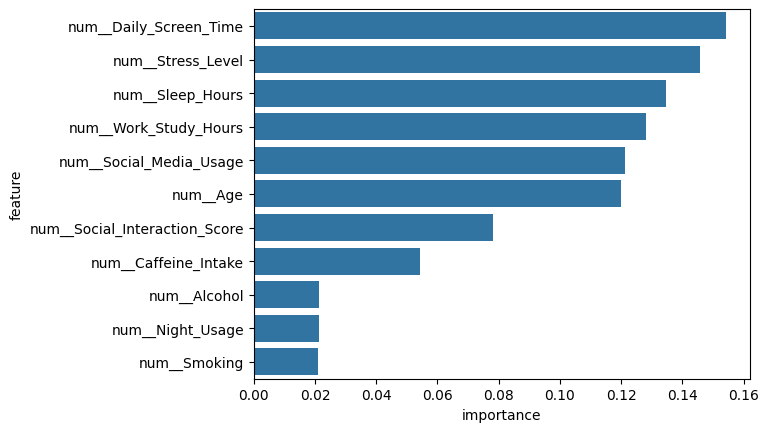

In [17]:
importances = gs_rf.best_estimator_.named_steps["model"].feature_importances_
feature_names = gs_rf.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)
sns.barplot(data=imp_df, x="importance", y="feature")

In [18]:
preprocessor = build_preprocessor(numeric_features,
                                  categorical_features,
                                  tree=True)

pipe_gb = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))

    ]
)


In [19]:
param_grid_gb = {
      "model__n_estimators": np.arange(100, 400, 100),
      "model__learning_rate": [0.05, 0.1],
      "model__max_depth": [3, 5],
      "model__min_samples_leaf": np.arange(1, 6),
      "model__subsample": [1.0, 0.8],
  }

In [20]:
gs_gb = train(Xtrain, ytrain, pipe_gb, param_grid_gb)
gs_gb.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 3,
 'model__min_samples_leaf': np.int64(5),
 'model__n_estimators': np.int64(100),
 'model__subsample': 1.0}

In [21]:
gs_gb.best_score_

np.float64(0.6402128742211609)

In [22]:
predict_gb = get_predict(gs_gb.best_estimator_, Xtest, return_proba=False)
proba_gb = get_predict(gs_gb.best_estimator_, Xtest, return_proba=True)
metrics_gb = get_metrics(ytest, predict_gb, proba_gb)
metrics_gb

{'accuracy': 0.605,
 'precision': 0.6060606060606061,
 'recall': 0.6,
 'f1': 0.6030150753768844,
 'roc_auc': 0.6265000000000001}

In [23]:
file_path = Path('../models/gradient_boosting.pkl').resolve()
model_dump(gs_gb.best_estimator_, file_path)

In [24]:
preprocessor_log_reg = build_preprocessor(numeric_features,
                                  categorical_features)

pipe_log_reg = Pipeline(
    [
        ("preprocessor", preprocessor_log_reg),
        ("model", LogisticRegression(C=0.01,
                                    penalty='l2',
                                    solver='lbfgs',
                                    random_state=42))

    ]
)

In [25]:
preprocessor_rf = build_preprocessor(numeric_features,
                                  categorical_features,
                                  tree=True)

pipe_rf = Pipeline(
    [
        ("preprocessor", preprocessor_rf),
        ("model", RandomForestClassifier(n_estimators=400,
                                       max_depth=10,
                                       min_samples_split=5,
                                       min_samples_leaf=2,
                                       max_features="sqrt",
                                       random_state=42))

    ]
)

In [26]:
preprocessor_gb = build_preprocessor(numeric_features,
                                    categorical_features,
                                    tree=True)

pipe_gb = Pipeline(
    [
        ("preprocessor", preprocessor_gb),
        ("model", GradientBoostingClassifier(learning_rate=0.05,
                                           max_depth=3,
                                           min_samples_leaf=4,
                                           n_estimators=100,
                                           subsample=1.0,
                                           random_state=42))

    ]
)

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stacking = StackingClassifier(
      estimators=[("lr", pipe_log_reg), ("rf", pipe_rf), ("gb", pipe_gb)],
      final_estimator=LogisticRegression(random_state=42),
      n_jobs=-1,
      cv=cv
  )

stacking.fit(Xtrain, ytrain)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can ref

In [28]:
stacking_predict = stacking.predict(Xtest)
stacking_proba = stacking.predict_proba(Xtest)[:,1]

metrics_stacking = get_metrics(ytest, stacking_predict, stacking_proba)
metrics_stacking

{'accuracy': 0.615,
 'precision': 0.6210526315789474,
 'recall': 0.59,
 'f1': 0.6051282051282051,
 'roc_auc': 0.6206750000000001}

In [29]:
model_dump(stacking, Path('../models/stacking.pkl').resolve())

## Сравнение моделей по ROC-AUC на тестовой выборке

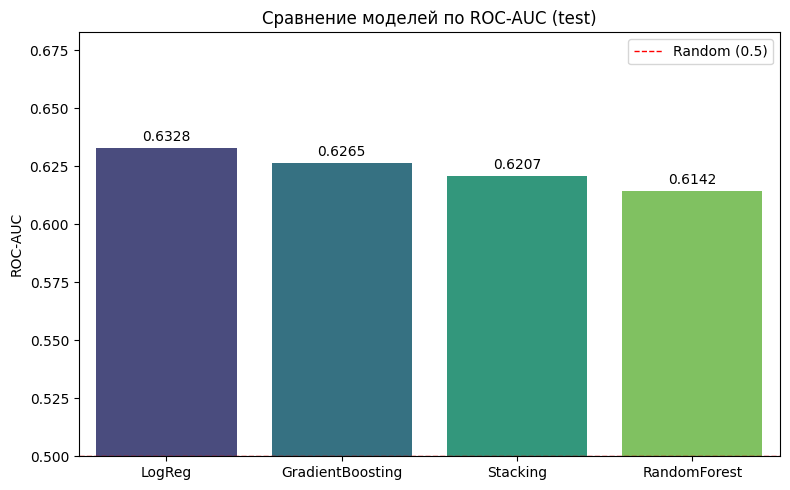

In [30]:
comparison = pd.DataFrame({
    "model": ["LogReg", "RandomForest", "GradientBoosting", "Stacking"],
    "roc_auc": [
        metrics_log_reg["roc_auc"],
        metrics_rf["roc_auc"],
        metrics_gb["roc_auc"],
        metrics_stacking["roc_auc"],
    ],
}).sort_values("roc_auc", ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=comparison, x="model", y="roc_auc", hue="model", palette="viridis", legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=10)

plt.ylim(0.5, max(comparison["roc_auc"]) + 0.05)
plt.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random (0.5)")
plt.title("Сравнение моделей по ROC-AUC (test)")
plt.ylabel("ROC-AUC")
plt.xlabel("")
plt.legend()
plt.tight_layout()
plt.show()

### Сохранение моделей в MLflow

In [35]:
import os
setup_mlflow()

2026/05/28 18:55:28 INFO mlflow.tracking.fluent: Experiment with name 'mental_health_depression' does not exist. Creating a new experiment.


In [36]:
log_experiment(
    run_name="logistic_regression",
    model= gs_log_reg.best_estimator_,
    params= gs_log_reg.best_params_,
    metrics= metrics_log_reg,
    tags={
          "model_type": "linear",
          "target": "Depression",
          "author": "Bogdan",
          "preprocessing": "scaler+poly",
      },
)

2026/05/28 18:55:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run logistic_regression at: http://localhost:5000/#/experiments/1/runs/4864a95892624a8c90144711a8fda983
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [37]:
log_experiment(
      run_name="random_forest",
      model=gs_rf.best_estimator_,
      params=gs_rf.best_params_,
      metrics=metrics_rf,
      tags={
          "model_type": "tree",
          "target": "Depression",
          "author": "Bogdan",
          "preprocessing": "passthrough",
      }
  )

2026/05/28 18:56:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run random_forest at: http://localhost:5000/#/experiments/1/runs/da6ef5c242264a77afa6e57947fd308f
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [38]:
log_experiment(
    run_name="gradient_boosting",
    model=gs_gb.best_estimator_,
    params=gs_gb.best_params_,
    metrics=metrics_gb,
    tags={
          "model_type": "tree",
          "target": "Depression",
          "author": "Bogdan",
          "preprocessing": "passthrough",
      },
)

2026/05/28 18:56:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run gradient_boosting at: http://localhost:5000/#/experiments/1/runs/7f62f7e82d3f4bfcbcd255b42d163ee6
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [39]:
log_experiment(
      run_name="stacking",
      model=stacking,
      params={"base_models": "lr+rf+gb"},
      metrics=metrics_stacking,
      tags={
          "model_type": "ensemble",
          "target": "Depression",
          "author": "Bogdan",
      }
  )

2026/05/28 18:56:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run stacking at: http://localhost:5000/#/experiments/1/runs/23e3e24c2f7943e4822e57f55ce81ebd
🧪 View experiment at: http://localhost:5000/#/experiments/1
